# 06. Target 품질 정책 검토

`05_target_build.ipynb`에서 생성한 `market_vwap` 기반 30일/60일 forward return 타겟의 품질 정책을 검토한다.

## 품질 기준 정의

| 개념 | 의미 |
|---|---|
| `actual_elapsed_days_30d/60d` | 기준일과 실제로 사용된 미래 VWAP 날짜 사이의 경과일. 주말, 휴일, 거래 공백 때문에 30일/60일보다 길어질 수 있음 |
| `elapsed_cap` | `actual_elapsed_days_*`가 지나치게 긴 행을 제외하기 위한 상한 후보 |
| `nominal_plus_5` | 30일 타겟은 35일 이하, 60일 타겟은 65일 이하만 유지하는 후보 |
| `nominal_plus_15` | 30일 타겟은 45일 이하, 60일 타겟은 75일 이하만 유지하는 후보 |

In [1]:
# 1. 환경 설정
from pathlib import Path
import os
from urllib.parse import quote_plus

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
from dotenv import load_dotenv
from sqlalchemy import create_engine

if Path('/mnt/hgfs/Windows/Climate').exists():
    PROJECT_ROOT = Path('/mnt/hgfs/Windows/Climate')
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == 'notebooks':
        PROJECT_ROOT = PROJECT_ROOT.parent

SAVE_OUTPUT = False

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 2. DB 연결 및 KRX ETS 원천 데이터 로드
load_dotenv(PROJECT_ROOT / '.env')
required_keys = ['DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD']
missing = [key for key in required_keys if not os.getenv(key)]
if missing:
    raise RuntimeError(f'필수 DB 환경변수가 없습니다: {missing}')

user = os.getenv('DB_USER')
password = quote_plus(os.getenv('DB_PASSWORD'))
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
db = os.getenv('DB_NAME')
engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{db}')

query = '''
select
    period,
    trd_dd,
    isu_code,
    clsprc,
    acc_trdvol,
    acc_trdval,
    vwap
from raw.krx_ets_daily
order by trd_dd, isu_code
'''

ets = pd.read_sql(query, engine, parse_dates=['trd_dd'])
ets['is_trade_day'] = (ets['acc_trdvol'] > 0) & (ets['vwap'] > 0)
ets_trade = ets[ets['is_trade_day']].copy().sort_values(['trd_dd', 'isu_code']).reset_index(drop=True)

source_summary = pd.DataFrame({
    '항목': [
        'raw.krx_ets_daily 전체 행 수',
        '실제 거래 행 수',
        '실제 거래가 있는 날짜 수',
        '시작일',
        '종료일',
        '실제 거래 빈티지 수',
    ],
    '값': [
        len(ets),
        len(ets_trade),
        ets_trade['trd_dd'].nunique(),
        ets['trd_dd'].min().date(),
        ets['trd_dd'].max().date(),
        ets_trade['isu_code'].nunique(),
    ],
})
source_summary

,항목,값
0,raw.krx_ets_daily 전체 행 수,8213
1,실제 거래 행 수,2385
2,실제 거래가 있는 날짜 수,2132
3,시작일,2015-01-12
4,종료일,2026-04-23
5,실제 거래 빈티지 수,11


In [3]:
# 3. market_vwap와 30일/60일 타겟 생성
def join_codes(codes):
    return ','.join(sorted(codes))

market_base = ets_trade.assign(
    weighted_vwap_value=ets_trade['vwap'] * ets_trade['acc_trdvol']
)

market_daily = (
    market_base
    .groupby('trd_dd', as_index=False)
    .agg(
        market_vwap=('weighted_vwap_value', 'sum'),
        total_trdvol=('acc_trdvol', 'sum'),
        total_trdval=('acc_trdval', 'sum'),
        n_vintages=('isu_code', 'nunique'),
        vintages=('isu_code', join_codes),
    )
    .sort_values('trd_dd')
    .reset_index(drop=True)
)
market_daily['market_vwap'] = market_daily['market_vwap'] / market_daily['total_trdvol']
market_daily['vwap_from_trdval'] = market_daily['total_trdval'] / market_daily['total_trdvol']
market_daily['vwap_check_abs_diff'] = (market_daily['market_vwap'] - market_daily['vwap_from_trdval']).abs()
market_daily['is_blended'] = market_daily['n_vintages'] >= 2
market_daily['price_policy'] = 'market_vwap'


def add_forward_return_targets(price_df, target_periods=(30, 60)):
    result = price_df.copy().sort_values('trd_dd').reset_index(drop=True)
    result['trd_dd'] = pd.to_datetime(result['trd_dd']).astype('datetime64[ns]')
    future_base = result[['trd_dd', 'market_vwap', 'total_trdvol', 'n_vintages', 'is_blended']].copy()
    for target_period in target_periods:
        future = future_base.rename(columns={
            'trd_dd': f'future_date_{target_period}d',
            'market_vwap': f'future_vwap_{target_period}d',
            'total_trdvol': f'future_trdvol_{target_period}d',
            'n_vintages': f'future_n_vintages_{target_period}d',
            'is_blended': f'future_is_blended_{target_period}d',
        }).sort_values(f'future_date_{target_period}d')
        lookup = result[['trd_dd']].copy()
        lookup['_row_id'] = np.arange(len(lookup))
        lookup[f'target_lookup_date_{target_period}d'] = lookup['trd_dd'] + pd.Timedelta(days=target_period)
        lookup = lookup.sort_values(f'target_lookup_date_{target_period}d')
        matched = pd.merge_asof(
            lookup,
            future,
            left_on=f'target_lookup_date_{target_period}d',
            right_on=f'future_date_{target_period}d',
            direction='forward',
        ).sort_values('_row_id')
        for col in [
            f'target_lookup_date_{target_period}d',
            f'future_date_{target_period}d',
            f'future_vwap_{target_period}d',
            f'future_trdvol_{target_period}d',
            f'future_n_vintages_{target_period}d',
            f'future_is_blended_{target_period}d',
        ]:
            result[col] = matched[col].values
        result[f'actual_elapsed_days_{target_period}d'] = (
            result[f'future_date_{target_period}d'] - result['trd_dd']
        ).dt.days
        result[f'target_logret_{target_period}d'] = np.log(
            result[f'future_vwap_{target_period}d'] / result['market_vwap']
        )
        result[f'target_direction_{target_period}d'] = np.where(
            result[f'target_logret_{target_period}d'].isna(),
            pd.NA,
            (result[f'target_logret_{target_period}d'] > 0).astype('Int64'),
        )
    return result

target_df = add_forward_return_targets(market_daily, target_periods=(30, 60))

market_summary = pd.DataFrame({
    '항목': [
        'market_vwap 관측치 수',
        '2개 이상 빈티지를 합친 날짜 수',
        '2개 이상 빈티지를 합친 날짜 비율',
        '거래대금 기반 VWAP와의 최대 절대 차이',
    ],
    '값': [
        len(target_df),
        int(target_df['is_blended'].sum()),
        target_df['is_blended'].mean(),
        target_df['vwap_check_abs_diff'].max(),
    ],
})
market_summary

,항목,값
0,market_vwap 관측치 수,2132.000000
1,2개 이상 빈티지를 합친 날짜 수,252.000000
2,2개 이상 빈티지를 합친 날짜 비율,0.118199
3,거래대금 기반 VWAP와의 최대 절대 차이,0.500000


In [4]:
# 4. actual_elapsed_days 원본 분포 확인
elapsed_rows = []
for target_period in [30, 60]:
    target_col = f'target_logret_{target_period}d'
    elapsed_col = f'actual_elapsed_days_{target_period}d'
    valid = target_df[target_col].notna()
    elapsed = target_df.loc[valid, elapsed_col]
    elapsed_rows.append({
        'target': target_col,
        'valid_obs': int(valid.sum()),
        'median_days': elapsed.median(),
        'p90_days': elapsed.quantile(0.90),
        'p95_days': elapsed.quantile(0.95),
        'p99_days': elapsed.quantile(0.99),
        'max_days': elapsed.max(),
        'over_nominal_plus_5': int((elapsed > target_period + 5).sum()),
        'over_nominal_plus_15': int((elapsed > target_period + 15).sum()),
    })

elapsed_summary = pd.DataFrame(elapsed_rows)
elapsed_summary_display = elapsed_summary.rename(columns={
    'target': '타겟',
    'valid_obs': '유효 타겟 수',
    'median_days': '실제 경과일 중앙값',
    'p90_days': '90% 분위',
    'p95_days': '95% 분위',
    'p99_days': '99% 분위',
    'max_days': '최대값',
    'over_nominal_plus_5': '예측 기간+5일 초과 수',
    'over_nominal_plus_15': '예측 기간+15일 초과 수',
})
elapsed_summary_display.style.format({
    '실제 경과일 중앙값': '{:.0f}',
    '90% 분위': '{:.0f}',
    '95% 분위': '{:.0f}',
    '99% 분위': '{:.0f}',
    '최대값': '{:.0f}',
})

,타겟,유효 타겟 수,실제 경과일 중앙값,90% 분위,95% 분위,99% 분위,최대값,예측 기간+5일 초과 수,예측 기간+15일 초과 수
0,target_logret_30d,2110,30,32,34,42,268,64,16
1,target_logret_60d,2089,60,62,64,72,268,61,15


In [5]:
# 5. elapsed_cap 후보별 표본 수와 분포 비교
policy_specs = [
    {'policy': 'no_elapsed_filter', 'cap_30d': None, 'cap_60d': None},
    {'policy': 'nominal_plus_5', 'cap_30d': 35, 'cap_60d': 65},
    {'policy': 'nominal_plus_15', 'cap_30d': 45, 'cap_60d': 75},
]

comparison_rows = []
for spec in policy_specs:
    for target_period in [30, 60]:
        target_col = f'target_logret_{target_period}d'
        elapsed_col = f'actual_elapsed_days_{target_period}d'
        cap = spec[f'cap_{target_period}d']
        valid = target_df[target_col].notna()
        if cap is not None:
            keep = valid & target_df[elapsed_col].le(cap)
        else:
            keep = valid
        x = target_df.loc[keep, target_col]
        elapsed = target_df.loc[keep, elapsed_col]
        comparison_rows.append({
            'policy': spec['policy'],
            'target': target_col,
            'elapsed_cap': cap if cap is not None else 'none',
            'base_obs': len(target_df),
            'valid_before_filter': int(valid.sum()),
            'kept_obs': int(keep.sum()),
            'removed_from_valid': int(valid.sum() - keep.sum()),
            'kept_rate_of_base': keep.mean(),
            'kept_rate_of_valid': keep.sum() / valid.sum(),
            'max_elapsed_after_filter': elapsed.max(),
            'mean': x.mean(),
            'std': x.std(),
            'min': x.min(),
            'median': x.median(),
            'max': x.max(),
            'positive_rate': (x > 0).mean(),
            'base_blended_rate': target_df.loc[keep, 'is_blended'].mean(),
            'future_blended_rate': target_df.loc[keep, f'future_is_blended_{target_period}d'].mean(),
        })

policy_comparison = pd.DataFrame(comparison_rows)
policy_comparison_display = policy_comparison.rename(columns={
    'policy': '정책 후보',
    'target': '타겟',
    'elapsed_cap': '실제 경과일 상한',
    'base_obs': '기준 관측치 수',
    'valid_before_filter': '필터 전 유효 타겟 수',
    'kept_obs': '유지 관측치 수',
    'removed_from_valid': '제외 관측치 수',
    'kept_rate_of_base': '전체 대비 유지율',
    'kept_rate_of_valid': '유효 타겟 대비 유지율',
    'max_elapsed_after_filter': '필터 후 실제 경과일 최대',
    'mean': '평균',
    'std': '표준편차',
    'min': '최소',
    'median': '중앙값',
    'max': '최대',
    'positive_rate': '상승 비율',
    'base_blended_rate': '기준일 blended 비율',
    'future_blended_rate': '미래일 blended 비율',
})
policy_comparison_display.style.format({
    '전체 대비 유지율': '{:.1%}',
    '유효 타겟 대비 유지율': '{:.1%}',
    '필터 후 실제 경과일 최대': '{:.0f}',
    '평균': '{:.4f}',
    '표준편차': '{:.4f}',
    '최소': '{:.4f}',
    '중앙값': '{:.4f}',
    '최대': '{:.4f}',
    '상승 비율': '{:.1%}',
    '기준일 blended 비율': '{:.1%}',
    '미래일 blended 비율': '{:.1%}',
})

,정책 후보,타겟,실제 경과일 상한,기준 관측치 수,필터 전 유효 타겟 수,유지 관측치 수,제외 관측치 수,전체 대비 유지율,유효 타겟 대비 유지율,필터 후 실제 경과일 최대,평균,표준편차,최소,중앙값,최대,상승 비율,기준일 blended 비율,미래일 blended 비율
0,no_elapsed_filter,target_logret_30d,none,2132,2110,2110,0,99.0%,100.0%,268,-0.0030,0.1447,-0.6070,0.0048,0.7201,52.7%,11.9%,11.4%
1,no_elapsed_filter,target_logret_60d,none,2132,2089,2089,0,98.0%,100.0%,268,-0.0065,0.2034,-0.6458,0.0013,0.9637,50.4%,12.1%,11.1%
2,nominal_plus_5,target_logret_30d,35,2132,2110,2046,64,96.0%,97.0%,35,-0.0046,0.1449,-0.6070,0.0038,0.7201,52.2%,12.2%,11.7%
3,nominal_plus_5,target_logret_60d,65,2132,2089,2028,61,95.1%,97.1%,65,-0.0087,0.2051,-0.6458,0.0000,0.9637,49.6%,12.2%,11.4%
4,nominal_plus_15,target_logret_30d,45,2132,2110,2094,16,98.2%,99.2%,44,-0.0033,0.1446,-0.6070,0.0047,0.7201,52.6%,12.0%,11.5%
5,nominal_plus_15,target_logret_60d,75,2132,2089,2074,15,97.3%,99.3%,75,-0.0073,0.2036,-0.6458,0.0003,0.9637,50.2%,12.1%,11.1%


In [ ]:
# 6. nominal_plus_15 기준에서 제외되는 긴 경과일 행 확인
long_gap_rows = []
for target_period, cap in [(30, 45), (60, 75)]:
    target_col = f'target_logret_{target_period}d'
    elapsed_col = f'actual_elapsed_days_{target_period}d'
    future_date_col = f'future_date_{target_period}d'
    future_vwap_col = f'future_vwap_{target_period}d'
    mask = target_df[target_col].notna() & target_df[elapsed_col].gt(cap)
    view = target_df.loc[mask, [
        'trd_dd', 'market_vwap', 'n_vintages', 'vintages', 'is_blended',
        future_date_col, future_vwap_col, elapsed_col, target_col,
    ]].copy()
    view.insert(0, 'target', target_col)
    view.insert(1, 'elapsed_cap', cap)
    view = view.rename(columns={
        future_date_col: 'future_date',
        future_vwap_col: 'future_vwap',
        elapsed_col: 'actual_elapsed_days',
        target_col: 'target_value',
    })
    long_gap_rows.append(view)

long_gap_cases = pd.concat(long_gap_rows, ignore_index=True)
long_gap_summary = (
    long_gap_cases
    .groupby(['target', 'elapsed_cap'], as_index=False)
    .agg(
        excluded_obs=('trd_dd', 'size'),
        start_date=('trd_dd', 'min'),
        end_date=('trd_dd', 'max'),
        max_elapsed_days=('actual_elapsed_days', 'max'),
    )
)

display(long_gap_summary)
display(long_gap_cases.head(20).style.format({
    'market_vwap': '{:,.2f}',
    'future_vwap': '{:,.2f}',
    'actual_elapsed_days': '{:.0f}',
    'target_value': '{:.4f}',
}))

,target,elapsed_cap,excluded_obs,start_date,end_date,max_elapsed_days
0,target_logret_30d,45,16,2015-01-12,2018-11-22,268.0
1,target_logret_60d,75,15,2015-01-12,2018-10-23,268.0


,target,elapsed_cap,trd_dd,market_vwap,n_vintages,vintages,is_blended,future_date,future_vwap,actual_elapsed_days,target_value
0,target_logret_30d,45,2015-01-12 00:00:00,"8,185.00",1,KAU15,False,2015-10-07 00:00:00,"11,300.00",268,0.3225
1,target_logret_30d,45,2015-01-13 00:00:00,"9,500.00",1,KAU15,False,2015-10-07 00:00:00,"11,300.00",267,0.1735
2,target_logret_30d,45,2015-01-14 00:00:00,"9,510.00",1,KAU15,False,2015-10-07 00:00:00,"11,300.00",266,0.1725
3,target_logret_30d,45,2015-01-16 00:00:00,"9,610.00",1,KAU15,False,2015-10-07 00:00:00,"11,300.00",264,0.1620
4,target_logret_30d,45,2015-10-07 00:00:00,"11,300.00",1,KAU15,False,2015-12-09 00:00:00,"12,100.00",63,0.0684
5,target_logret_30d,45,2015-10-08 00:00:00,"12,050.00",1,KAU15,False,2015-12-09 00:00:00,"12,100.00",62,0.0041
6,target_logret_30d,45,2016-02-22 00:00:00,"14,400.00",1,KAU15,False,2016-04-11 00:00:00,"18,500.00",49,0.2505
7,target_logret_30d,45,2016-02-23 00:00:00,"15,800.00",1,KAU15,False,2016-04-11 00:00:00,"18,500.00",48,0.1578
8,target_logret_30d,45,2018-07-16 00:00:00,"28,000.00",1,KAU17,False,2018-09-05 00:00:00,"21,600.00",51,-0.2595
9,target_logret_30d,45,2018-07-17 00:00:00,"25,200.00",1,KAU17,False,2018-09-05 00:00:00,"21,600.00",50,-0.1542


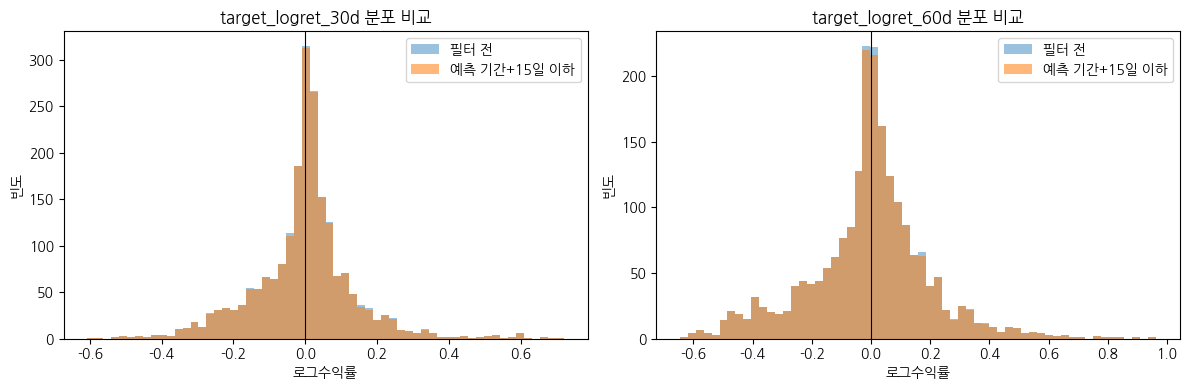

In [7]:
# 7. 후보 정책별 수익률 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, target_period in zip(axes, [30, 60]):
    target_col = f'target_logret_{target_period}d'
    elapsed_col = f'actual_elapsed_days_{target_period}d'
    valid = target_df[target_col].notna()
    no_filter = target_df.loc[valid, target_col]
    plus_15 = target_df.loc[valid & target_df[elapsed_col].le(target_period + 15), target_col]
    ax.hist(no_filter, bins=60, alpha=0.45, label='필터 전')
    ax.hist(plus_15, bins=60, alpha=0.55, label='예측 기간+15일 이하')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{target_col} 분포 비교')
    ax.set_xlabel('로그수익률')
    ax.set_ylabel('빈도')
    ax.legend()
fig.tight_layout()
plt.show()

In [ ]:
# 8. 결론 후보
recommended_policy = pd.DataFrame([
    {
        '항목': '메인 가격 정책',
        '판단': 'market_vwap 유지',
        '근거': '특정 빈티지 하나를 선택하지 않고 날짜별 실제 거래 전체를 집계한다.',
    },
    {
        '항목': '30일 타겟 품질 후보',
        '판단': 'actual_elapsed_days_30d <= 45 후보',
        '근거': '30일 예측 문제에서 과도한 거래 공백 행을 제외하면서 표본 손실을 제한한다.',
    },
    {
        '항목': '60일 타겟 품질 후보',
        '판단': 'actual_elapsed_days_60d <= 75 후보',
        '근거': '60일 예측 문제에서 과도한 거래 공백 행을 제외하면서 표본 손실을 제한한다.',
    },
    {
        '항목': '저장 여부',
        '판단': '아직 저장하지 않음',
        '근거': '품질 필터 적용 여부를 확인한 뒤 05 또는 후속 저장 노트에서 SAVE_OUTPUT을 켠다.',
    },
])
recommended_policy

,항목,판단,근거
0,메인 가격 정책,market_vwap 유지,특정 빈티지 하나를 선택하지 않고 날짜별 실제 거래 전체를 집계한다.
1,30일 타겟 품질 후보,actual_elapsed_days_30d <= 45 후보,30일 예측 문제에서 과도한 거래 공백 행을 제외하면서 표본 손실을 제한한다.
2,60일 타겟 품질 후보,actual_elapsed_days_60d <= 75 후보,60일 예측 문제에서 과도한 거래 공백 행을 제외하면서 표본 손실을 제한한다.
3,저장 여부,아직 저장하지 않음,품질 필터 적용 여부를 확인한 뒤 05 또는 후속 저장 노트에서 SAVE_OUTPU...
